# Disaggregation

## AvgSA[0,3]

In [ ]:
disagg_data_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_data_60sites.pickle"
disagg_stats_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_stats_60sites.pickle" 

dstore = read(calc_id_avgSA_03_disagg)
disagg_type = 'TRT_Mag_Dist_Eps'

bins = get_bins(dstore, disagg_type)
# get data from datastore and group by seismicity/region
groups_disagg = group_disagg_data(groups, site_metadata, dstore, 
                                disagg_type, traditional=True, occurence=True)
hmaps = dstore["hmaps-stats"]
disagg_stats = get_disagg_stats_from_groups(groups_disagg, site_metadata,
                                            hmaps, geodf=False)

# pickle the disaggregation results for later use
disagg_data_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_data_60sites.pickle"
disagg_stats_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_stats_60sites.pickle"

with open(disagg_data_fp, "wb") as file:
    pickle.dump(groups_disagg, file)

with open(disagg_stats_fp, "wb") as file:
    pickle.dump(disagg_stats, file)

disagg_data_AvgSA_03 = groups_disagg
disagg_stats_AvgSA_03 = disagg_stats
print("Disaggreation data loaded from openquake and processed...")

Disaggreation data loaded from openquake and processed...


In [ ]:
# plot the normalised imts
df = disagg_stats_AvgSA_03.pivot(index="site_id", columns="poe", values="imtl")
mafes = [-np.log(1-float(poe)) for poe in df.columns]
normed_imtls = df.to_numpy() / df[0.002103].to_numpy().reshape((-1, 1))
normed_imtls = pd.DataFrame(normed_imtls, index=df.index, columns=df.columns)

grouped_sites = disagg_stats_AvgSA_03.groupby(['seismicity', 'region'])['site_id'].unique()
site_lists = grouped_sites.to_dict()

[]

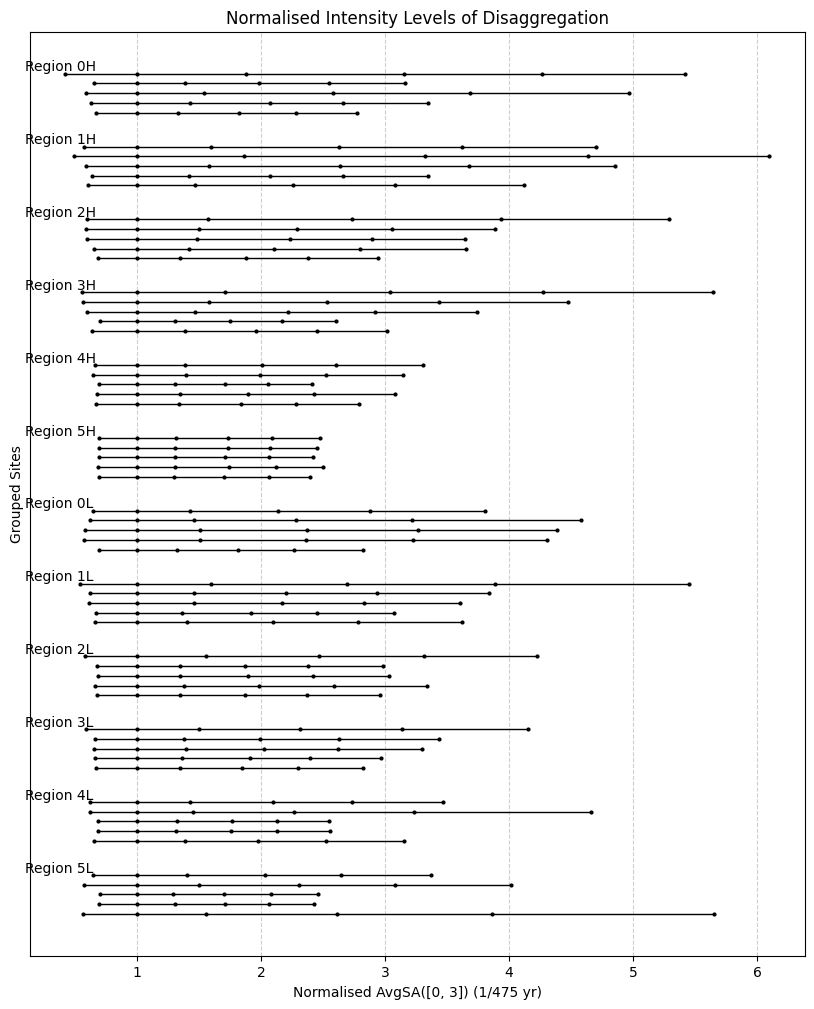

In [ ]:
row_spacing = 0.2   # Gap between rows in a group
group_spacing = 1.5 # Gap between different groups

fig, ax = plt.subplots(figsize=(10, 12))

for ii, ((s,r), sites) in enumerate(site_lists.items()):
    for jj, site_id in enumerate(sites):
        imls = normed_imtls.loc[site_id, :]
        
        # Calculate y-coordinate with group offset
        y_pos = (ii * group_spacing) + (jj * row_spacing)

        # Plot horizontal line with dots
        plt.plot(imls, [y_pos] * len(imls), marker='.', color="k", 
                 linestyle='-', linewidth=1, markersize=4)
        
        if jj == 0:
            ax.text(0.1, y_pos-0.06, f"Region {r}{s.capitalize()[0]}")

ax.set_xlabel("Normalised AvgSA([0, 3]) (1/475 yr)")
ax.set_ylabel("Grouped Sites")
ax.set_title("Normalised Intensity Levels of Disaggregation")
ax.invert_yaxis() # Optional: keep row 0 at the top
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_yticks([])

In [ ]:
# calculate the % ASC for each site and POE  -> already in disagg_stats
df = disagg_stats_AvgSA_03
poes = df["poe"].unique()
poe_dfs = {poe: df[df["poe"] == poe] for poe in poes}
poe_seismicity_dfs = {poe: {s: df[df["seismicity"] == s] for s in df["seismicity"].unique()} for poe, df in poe_dfs.items()}

asc_prct_stat_dfs = {}
for poe, seismicity_dfs in poe_seismicity_dfs.items():
    for seismicity, df in seismicity_dfs.items():
        asc_prct_stat_dfs[(seismicity, poe)] = df["Shallow Default [%]"].describe()


Text(0, 0.5, '% Active Shallow Crust Events')

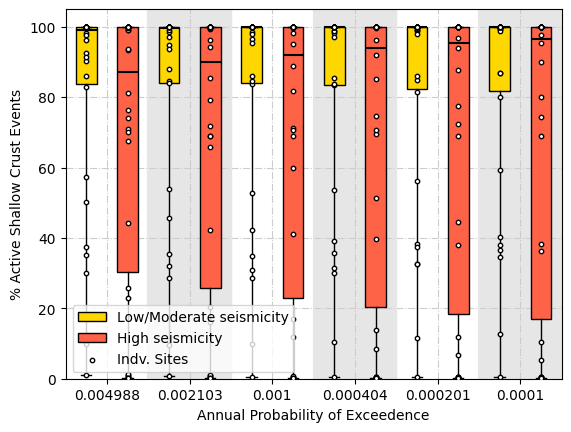

In [ ]:
# Plot a box and whisker plot for the distributions of % ASC for all sites at each RTP
seismicity_colours = {"high": "tomato",
                      "lowmod": "gold"}

cols_lowmod = [("lowmod", poe) for poe in poes]
cols_high = [("high", poe) for poe in poes]

def extract_stats(df_desc, col):
    s = df_desc[col]
    return {
        'med': s['50%'], 'q1': s['25%'], 'q3': s['75%'],
        'whislo': s['min'], 'whishi': s['max'], 'mean': s['mean']
    }


stats = []
colours = []
sites = []

for cl, ch in zip(cols_lowmod, cols_high):
    stats.append(extract_stats(asc_prct_stat_dfs, cl))
    stats.append(extract_stats(asc_prct_stat_dfs, ch))
    colours.append(seismicity_colours["lowmod"])
    colours.append(seismicity_colours["high"])

    sites.append(disagg_stats_AvgSA_03[(disagg_stats_AvgSA_03["seismicity"] == cl[0]) &
                           (disagg_stats_AvgSA_03["poe"] == cl[1])])

    sites.append(disagg_stats_AvgSA_03[(disagg_stats_AvgSA_03["seismicity"] == ch[0]) &
                           (disagg_stats_AvgSA_03["poe"] == ch[1])])
    

    # labels_lvl0.append(str(col[0]))
    # labels_lvl1.append(str(col[1]))


fig, ax = plt.subplots()

# Create the boxplot
bp = ax.bxp(stats, showmeans=False, 
            patch_artist=True, 
            showfliers=False,
            meanline=False)

# assign colours
for patch, colour in zip(bp["boxes"], colours):
    patch.set_facecolor(colour)
    patch.set_edgecolor("k")

for line in bp["medians"]:
    line.set_color("k")
    line.set_linewidth(1.5)

# for line in bp["means"]:
#     line.set_dashes((2,1))
#     line.set_color("k")

# overlay sites
x_pos = np.array([line.get_xdata()[0] for line in bp["medians"]])
x_off = 0.25
for s, x in zip(sites, x_pos+x_off):
    xs = np.full(len(s["Shallow Default [%]"]), x)
    scat1 = ax.scatter(xs, s["Shallow Default [%]"], zorder=5, s=10, edgecolors="k", c="w", 
               label="sites")

# Set x-tick positions
# X positions: 1..12
pos = np.arange(1, len(stats)+1)

# Tick: one per region, centred between the two boxes
tick_pos = pos.reshape(-1, 2).mean(axis=1)
# region_labels = [f"R{r}\n{atten_label_map[r]}" for r in regions]
ax.set_xticks(tick_pos)
ax.set_xticklabels(poes, rotation=0)

# --- Shading odd-numbered regions (1,3,5) ---
# Each region covers 2 box positions
for i in range(len(regions)):
    if i % 2 == 1:       # odd region index
        left = 2*i + 1   # first box position for this region
        right = 2*i + 2  # second box
        ax.axvspan(left - 0.5, right + 0.5, color='0.9')

# Draw vertical separators between each region group
for sep in range(1, len(regions)):
    ax.axvline(x=2*sep + 0.5, color='0.9', linestyle='-')

ax.grid(True, which="both", color="0.8", ls=("-."))

# ------------------------------------------------------------
# Collect ONE representative handle for each scatter type
# ------------------------------------------------------------
handle_sites = None
handle_mean = None

for h in ax.collections:
    lbl = h.get_label()
    if lbl == "sites" and handle_sites is None:
        handle_sites = h
    if lbl == "mean (sites)" and handle_mean is None:
        handle_mean = h

# ------------------------------------------------------------
# Create legend entries for seismicity (box colours)
# ------------------------------------------------------------
low_patch = mpatches.Patch(facecolor=seismicity_colours["lowmod"],
                           edgecolor='black')
high_patch = mpatches.Patch(facecolor=seismicity_colours["high"],
                            edgecolor='black')

# ------------------------------------------------------------
# Combine everything into one legend
# ------------------------------------------------------------
handles = [low_patch, high_patch, handle_sites]
labels  = ['Low/Moderate seismicity', 'High seismicity', "Indv. Sites"]

ax.legend(handles, labels, frameon=True,
          loc='lower left')

ax.set_ylim(0,)
ax.set_xlabel('Annual Probability of Exceedence')
ax.set_ylabel("% Active Shallow Crust Events")
# ax.legend(hs_neu, ls_neu, loc="upper left")


## AvgSA[0,6]

In [ ]:
disagg_data_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
disagg_stats_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle" 

dstore = read(calc_id_avgSA_06_disagg)
disagg_type = 'TRT_Mag_Dist_Eps'

bins = get_bins(dstore, disagg_type)
# get data from datastore and group by seismicity/region
groups_disagg = group_disagg_data(groups, site_metadata, dstore, 
                                disagg_type, traditional=True, occurence=True)
hmaps = dstore["hmaps-stats"]
disagg_stats = get_disagg_stats_from_groups(groups_disagg, site_metadata,
                                            hmaps, geodf=False)

# pickle the disaggregation results for later use
disagg_data_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
disagg_stats_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"

with open(disagg_data_fp, "wb") as file:
    pickle.dump(groups_disagg, file)

with open(disagg_stats_fp, "wb") as file:
    pickle.dump(disagg_stats, file)

disagg_data_AvgSA_06 = groups_disagg
disagg_stats_AvgSA_06 = disagg_stats
print("Disaggreation data loaded from openquake and processed...")

Disaggreation data loaded from openquake and processed...


In [ ]:
# plot the normalised imts
df = disagg_stats_AvgSA_06.pivot(index="site_id", columns="poe", values="imtl")
mafes = [-np.log(1-float(poe)) for poe in df.columns]
normed_imtls = df.to_numpy() / df[0.002103].to_numpy().reshape((-1, 1))
normed_imtls = pd.DataFrame(normed_imtls, index=df.index, columns=df.columns)

grouped_sites = disagg_stats_AvgSA_06.groupby(['seismicity', 'region'])['site_id'].unique()
site_lists = grouped_sites.to_dict()

[]

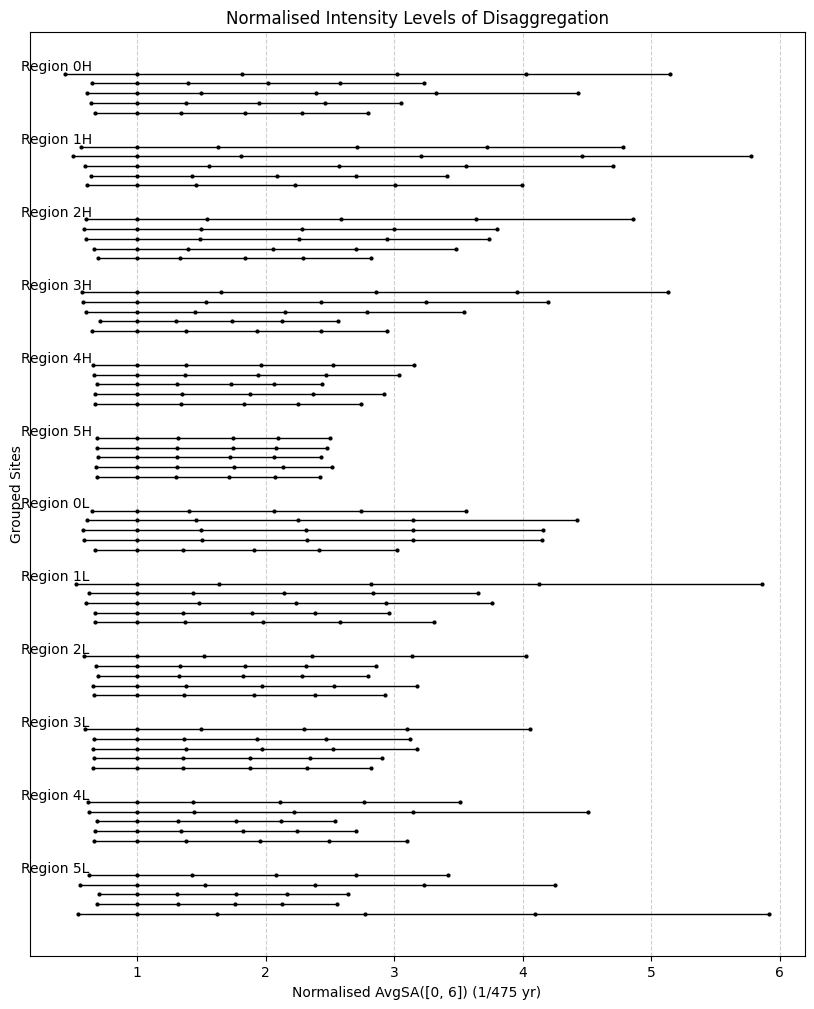

In [ ]:
row_spacing = 0.2   # Gap between rows in a group
group_spacing = 1.5 # Gap between different groups

fig, ax = plt.subplots(figsize=(10, 12))

for ii, ((s,r), sites) in enumerate(site_lists.items()):
    for jj, site_id in enumerate(sites):
        imls = normed_imtls.loc[site_id, :]
        
        # Calculate y-coordinate with group offset
        y_pos = (ii * group_spacing) + (jj * row_spacing)

        # Plot horizontal line with dots
        plt.plot(imls, [y_pos] * len(imls), marker='.', color="k", 
                 linestyle='-', linewidth=1, markersize=4)
        
        if jj == 0:
            ax.text(0.1, y_pos-0.06, f"Region {r}{s.capitalize()[0]}")

ax.set_xlabel("Normalised AvgSA([0, 6]) (1/475 yr)")
ax.set_ylabel("Grouped Sites")
ax.set_title("Normalised Intensity Levels of Disaggregation")
ax.invert_yaxis() # Optional: keep row 0 at the top
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_yticks([])